In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("../datasets/dataset_fraud_payroll.csv")

In [3]:
df.head()

,employee_id,department,position,salary_system,salary_received,salary_difference,fraud_flag
0,EMP1000,Operations,Manager,9184502,7286274,1898228,1
1,EMP1001,Marketing,Senior Staff,8892680,8892680,0,0
2,EMP1002,IT,Supervisor,10561000,9738290,822710,1
3,EMP1003,Marketing,Manager,10671458,10671458,0,0
4,EMP1004,Marketing,Staff,8892306,8892306,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   employee_id        148 non-null    str  
 1   department         148 non-null    str  
 2   position           148 non-null    str  
 3   salary_system      148 non-null    int64
 4   salary_received    148 non-null    int64
 5   salary_difference  148 non-null    int64
 6   fraud_flag         148 non-null    int64
dtypes: int64(4), str(3)
memory usage: 8.2 KB


In [5]:
df.isnull().sum()

employee_id          0
department           0
position             0
salary_system        0
salary_received      0
salary_difference    0
fraud_flag           0
dtype: int64

In [6]:
df = df.drop("employee_id", axis=1)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["department"] = le.fit_transform(df["department"])
df["position"] = le.fit_transform(df["position"])

In [8]:
X = df.drop("fraud_flag", axis=1)
y = df["fraud_flag"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0

In [13]:
import pickle

pickle.dump(
    model,
    open("../models/payroll_model.pkl", "wb")
)

In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

In [15]:
df.shape

(148, 6)

In [16]:
df["fraud_flag"].value_counts(normalize=True) * 100

fraud_flag
1    56.756757
0    43.243243
Name: proportion, dtype: float64

In [17]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[12,  0],
       [ 0, 18]])

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        18

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,salary_difference,0.837053
3,salary_received,0.084320
2,salary_system,0.057145
0,department,0.015087
1,position,0.006393


In [20]:
importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
4,salary_difference,0.837053
3,salary_received,0.084320
2,salary_system,0.057145
0,department,0.015087
1,position,0.006393


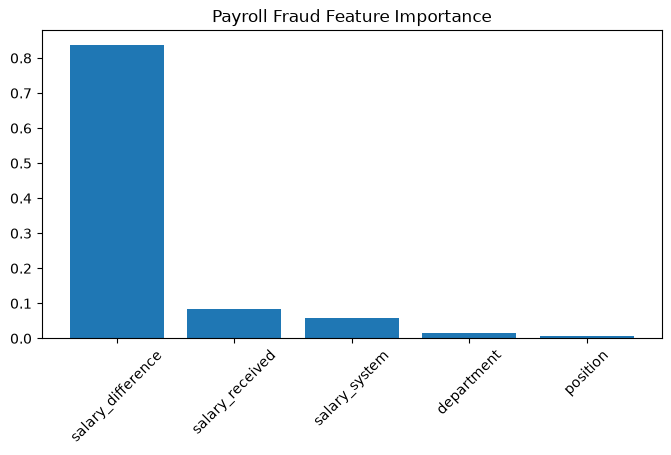

In [21]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,4))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xticks(rotation=45)
plt.title("Payroll Fraud Feature Importance")
plt.show()

In [22]:
import pickle

pickle.dump(
    model,
    open("../models/payroll_model.pkl", "wb")
)